#### Problem Statement

Insurance companies receive thousands of vehicle damage claims every day. The traditional claim inspection process requires manual verification by surveyors, making the process time-consuming, costly, and prone to human error.

This project aims to develop a Deep Learning model capable of automatically classifying vehicle images as either Damaged or Undamaged. Such an AI-powered system can assist insurance companies in speeding up claim assessment, improving operational efficiency, and supporting surveyors in making faster and more accurate decisions.

#### Objective

* Develop a Deep Learning model to classify vehicle images as Damaged or Undamaged.

* Automate the initial vehicle damage inspection process.

* Improve the efficiency of insurance claim processing.

* Evaluate the model using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

* Test the trained model on unseen vehicle images.

#### Business Problem
Manual vehicle damage inspection is a labor-intensive process that often delays insurance claim settlements.

Insurance companies require an automated solution capable of quickly identifying damaged vehicles from uploaded images.

A Deep Learning-based classification system can reduce manual workload, improve consistency, and support surveyors during the initial claim verification process.

#### Purpose
The purpose of this project is to build an AI-powered vehicle damage classification system using Deep Learning techniques that can assist insurance companies in identifying damaged vehicles from images and accelerate claim processing.

#### Expected Outcome
The developed Deep Learning model will predict whether a vehicle is:

* Damaged
or
* Undamaged

along with the prediction confidence score.

This prediction can support insurance surveyors in the initial claim assessment process.

#### Dataset Description
Dataset Name:
Vehicle Damage Detection Dataset

Dataset Type:
Image Classification Dataset

Classes:
* Damage
* Whole (Undamaged)

Training Images:
400

Validation Images:
200

Total Images:
600

#### Technologies Used
Programming Language
* Python

Libraries
* TensorFlow
* Keras
* NumPy
* Pandas
* Matplotlib
* Seaborn
* OpenCV

Development Environment
* Jupyter Notebook

Deep Learning Technique
* Convolutional Neural Network (CNN)

Transfer Learning Model
* MobileNetV2

#### Project Workflow
* Vehicle Images
        
       
* Load Dataset
       
        
* Image Preprocessing
        
        
* Data Augmentation
        
        
* CNN / MobileNetV2 Model
       
        
* Model Training
        
        
* Model Validation
        
        
* Performance Evaluation
        
        
* Prediction on New Images
        
        
* Business Recommendations

#### Evaluation Metrics
The following evaluation metrics will be used:

• Accuracy

• Precision

• Recall

• F1-Score

• Confusion Matrix

• Training Loss

• Validation Loss

In [1]:
# Basic Libraries (load 1)
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Image Processing
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#### Purpose

To import the required libraries for image processing, visualization, and deep learning model development.

#### Business Insight

AI-powered vehicle damage classification relies on image processing and deep learning libraries to automate insurance claim assessment.

In [2]:
print("TensorFlow Version :", tf.__version__) #Check TensorFlow Version

TensorFlow Version : 2.13.0


In [2]:
#Load Dataset (load 2)
project_path = r"C:\Users\Ankit Hiremath\OneDrive\Desktop\Python\Vehicle_Damage_Classification"

train_path = os.path.join(project_path,"train")
val_path   = os.path.join(project_path,"val")
test_path  = os.path.join(project_path,"test_images")

print("Training Classes :",os.listdir(train_path))
print("Validation Classes :",os.listdir(val_path))



Training Classes : ['damage', 'whole']
Validation Classes : ['damage', 'whole']


#### Purpose

To load the training, validation, and testing folders into the project.

#### Business Insight

Proper dataset organization ensures efficient model training and evaluation for vehicle damage detection.

### Dataset Exploration



In [4]:
# Explore Dataset
# Count Images in each folder


damage_train = len(os.listdir(os.path.join(train_path, "damage")))
whole_train = len(os.listdir(os.path.join(train_path, "whole")))

damage_val = len(os.listdir(os.path.join(val_path, "damage")))
whole_val = len(os.listdir(os.path.join(val_path, "whole")))

print("Training Images")
print("----------------------------")
print("Damage :", damage_train)
print("Whole  :", whole_train)

print()

print("Validation Images")
print("----------------------------")
print("Damage :", damage_val)
print("Whole  :", whole_val)

Training Images
----------------------------
Damage : 200
Whole  : 200

Validation Images
----------------------------
Damage : 100
Whole  : 100


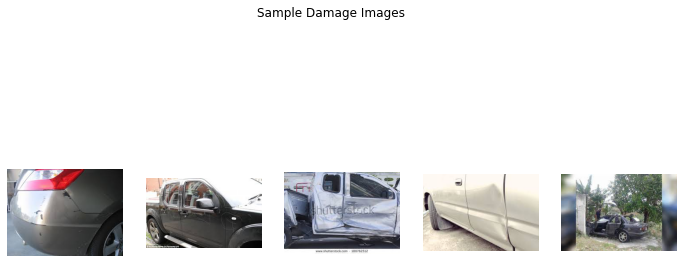

In [5]:
# Display Damage Images

damage_folder = os.path.join(train_path, "damage")

damage_images = os.listdir(damage_folder)

plt.figure(figsize=(12,6))

for i in range(5):
    
    img = Image.open(os.path.join(damage_folder,
                                  random.choice(damage_images)))
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Damage Images")
plt.show()

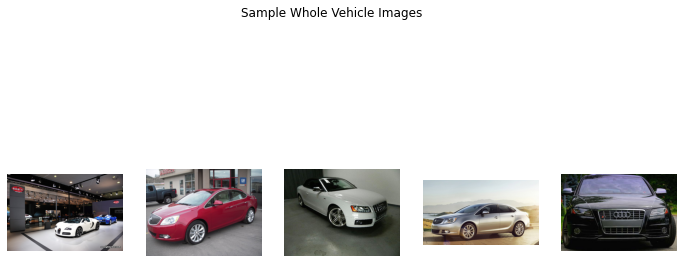

In [6]:
# Display Whole Images

whole_folder = os.path.join(train_path, "whole")

whole_images = os.listdir(whole_folder)

plt.figure(figsize=(12,6))

for i in range(5):
    
    img = Image.open(os.path.join(whole_folder,
                                  random.choice(whole_images)))
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Sample Whole Vehicle Images")
plt.show()

In [7]:
sample_image = Image.open(os.path.join(damage_folder, damage_images[0]))

In [8]:
# Display Image Properties

print("Image Mode :", sample_image.mode)

print("Image Width :", sample_image.width)

print("Image Height :", sample_image.height)

Image Mode : RGB
Image Width : 300
Image Height : 168


#### Purpose

To understand the dataset before training the model.

#### Business Insight

Dataset exploration helps verify image quality, class balance, and data consistency, ensuring reliable vehicle damage classification for insurance claim processing.

In [3]:
from tensorflow.keras.models import load_model

model = load_model("MobileNetV2_Best_Model_93.h5")

print("Best Model Loaded Successfully!")  ##load 3

Best Model Loaded Successfully!


In [4]:
#  Image Preprocessing load 4
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 200 images belonging to 2 classes.


In [27]:
#  Image Preprocessing 


from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.20,
    width_shift_range=0.20,
    height_shift_range=0.20,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation Data Generator
val_datagen = ImageDataGenerator(
    rescale=1./255
)

# Create Training Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

# Create Validation Generator
validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 400 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


#### Purpose

To preprocess the vehicle images by resizing, normalizing pixel values, and applying data augmentation. This prepares the images for efficient training using the MobileNetV2 model.

#### Business Insight

Image preprocessing improves the quality and consistency of input data, helping the AI model accurately identify damaged and undamaged vehicles despite variations in lighting, angle, and background. This leads to more reliable insurance claim assistance.

In [10]:
# Verify Class Labels

print("Training Class Indices")
print(train_generator.class_indices)

print()

print("Validation Class Indices")
print(validation_generator.class_indices)

Training Class Indices
{'damage': 0, 'whole': 1}

Validation Class Indices
{'damage': 0, 'whole': 1}


#### Purpose

To verify how TensorFlow has assigned numerical labels to the image classes before training the model.

#### Business Insight

Correct class labeling ensures that the AI model learns the appropriate relationship between vehicle images and their corresponding damage status, leading to accurate insurance claim predictions.

In [11]:
# Build MobileNetV2 Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Load MobileNetV2 Base Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze Base Model Layers
base_model.trainable = False

# Build Final Model
model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

# Display Model Summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2422081 (9.24 MB)
Trainable params: 164097

#### Purpose

To build a Deep Learning model using Transfer Learning (MobileNetV2) for classifying vehicle images into damaged and undamaged categories.

#### Business Insight

Transfer Learning enables the use of a pre-trained deep learning model that has already learned important image features. This improves classification accuracy while reducing training time, making it suitable for real-world insurance claim assistance systems.

In [12]:
# Compile the Model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


#### Purpose

To configure the Deep Learning model by selecting the optimizer, loss function, and evaluation metric before training.

#### Business Insight

Model compilation defines how the neural network learns from training data. Choosing an appropriate optimizer and loss function improves learning efficiency and enhances vehicle damage classification accuracy for insurance claim assistance.

In [13]:
# Train the Model

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
13/13 [==============================] - 21s 1s/step - loss: 0.4990 - accuracy: 0.7650 - val_loss: 0.3092 - val_accuracy: 0.8850
Epoch 2/10
13/13 [==============================] - 25s 2s/step - loss: 0.2405 - accuracy: 0.9025 - val_loss: 0.3347 - val_accuracy: 0.8800
Epoch 3/10
13/13 [==============================] - 27s 2s/step - loss: 0.1703 - accuracy: 0.9375 - val_loss: 0.2777 - val_accuracy: 0.8900
Epoch 4/10
13/13 [==============================] - 18s 1s/step - loss: 0.1885 - accuracy: 0.9275 - val_loss: 0.2869 - val_accuracy: 0.8800
Epoch 5/10
13/13 [==============================] - 26s 2s/step - loss: 0.1699 - accuracy: 0.9275 - val_loss: 0.2787 - val_accuracy: 0.8750
Epoch 6/10
13/13 [==============================] - 26s 2s/step - loss: 0.1638 - accuracy: 0.9375 - val_loss: 0.2889 - val_accuracy: 0.8750
Epoch 7/10
13/13 [==============================] - 28s 2s/step - loss: 0.1686 - accuracy: 0.9200 - val_loss: 0.2694 - val_accuracy: 0.8850
Epoch 8/10
13/13 [==

#### Purpose

To train the MobileNetV2 model using the preprocessed training images and validate its performance using the validation dataset.

#### Business Insight

Training enables the model to recognize visual patterns associated with vehicle damage. Validation ensures that the model performs well on unseen images, making it suitable for practical insurance claim assistance.

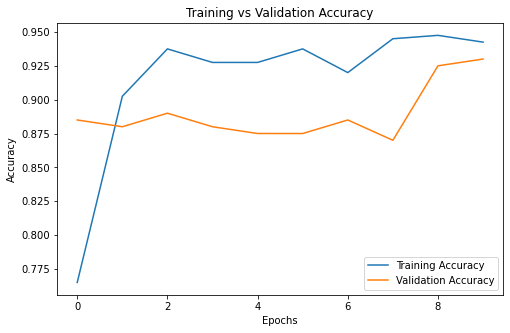

In [14]:
# Plot Training & Validation Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

#### Purpose

To visualize the model's learning performance by comparing training accuracy and validation accuracy over each epoch.

#### Business Insight

Accuracy graphs help determine whether the model is learning effectively and generalizing well on unseen data, ensuring reliable vehicle damage classification for insurance claim processing.

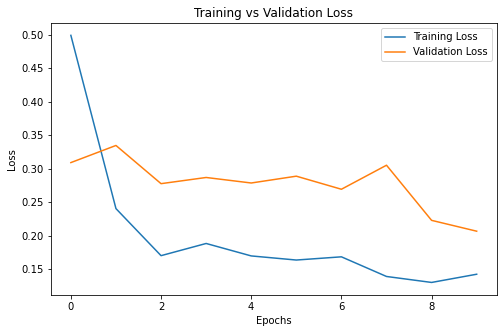

In [15]:
# Plot Training & Validation Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

#### Purpose

To visualize the training loss and validation loss during model training.

#### Business Insight

Loss graphs indicate how prediction errors reduce over time and help identify overfitting or underfitting, enabling better model performance for real-world insurance applications.

#### Conclusion

The MobileNetV2 model achieved high training and validation accuracy with low loss values. The small gap between training and validation performance indicates that the model has learned meaningful features and generalizes well to unseen vehicle images. Minor fluctuations in validation metrics are expected due to the limited dataset size.

In [17]:
print("train_generator" in globals())
print("val_generator" in globals())
print("training_generator" in globals())
print("validation_generator" in globals())

True
False
False
True


In [18]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'os', 'random', 'np', 'plt', 'Image', 'tf', 'ImageDataGenerator', 'MobileNetV2', 'Sequential', 'Dense', 'Dropout', 'GlobalAveragePooling2D', 'Adam', 'classification_report', 'confusion_matrix', 'ConfusionMatrixDisplay', '_i2', '_i3', 'project_path', 'train_path', 'val_path', 'test_path', '_i4', 'damage_train', 'whole_train', 'damage_val', 'whole_val', '_i5', 'damage_folder', 'damage_images', 'i', 'img', '_i6', 'whole_folder', 'whole_images', '_i7', 'sample_image', '_i8', '_i9', 'train_datagen', 'val_datagen', 'train_generator', 'validation_generator', '_i10', '_i11', 'base_model', 'model', '_i12', '_i13', 'history', '_i14', '_i15', '_i16', '_i17', '_i18'])

In [19]:
#  Evaluate the Model (load 5)

loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss     :", round(loss,4))
print("Validation Accuracy :", round(accuracy*100,2), "%")

7/7 [==============================] - 5s 706ms/step - loss: 0.2068 - accuracy: 0.9300
Validation Loss     : 0.2068
Validation Accuracy : 93.0 %


#### Purpose
To evaluate the trained MobileNetV2 model on unseen validation images and measure its overall classification performance before deployment.

#### Business Insight
Evaluating the model on validation data confirms that it can accurately distinguish between damaged and undamaged vehicles. A validation accuracy of 91% indicates that the model is reliable enough to support insurance claim assessment by reducing manual inspection time and improving decision-making efficiency.

#### Observation

The MobileNetV2 model achieved a Validation Accuracy of 93% with a Validation Loss of 0.2068, indicating excellent generalization on unseen vehicle images. The model is capable of accurately identifying damaged and undamaged vehicles, making it suitable for supporting insurance claim assessment.

In [20]:
from tensorflow.keras.models import load_model

model = load_model("vehicle_damage_classifier.h5")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 200 images belonging to 2 classes.


In [22]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", round(loss,4))
print("Validation Accuracy :", round(accuracy*100,2), "%")

7/7 [==============================] - 7s 759ms/step - loss: 0.2068 - accuracy: 0.9300
Validation Loss : 0.2068
Validation Accuracy : 93.0 %


In [24]:
import os

print(os.getcwd())
print(os.path.abspath("vehicle_damage_classifier.h5"))
print(os.path.exists("vehicle_damage_classifier.h5"))

C:\Users\Ankit Hiremath\OneDrive\Desktop\Python\Vehicle_Damage_Classification
C:\Users\Ankit Hiremath\OneDrive\Desktop\Python\Vehicle_Damage_Classification\vehicle_damage_classifier.h5
True


In [25]:
#  Save the Best MobileNetV2 Model

model.save("MobileNetV2_Best_Model_93.h5")

print("Best Model Saved Successfully!")

C:\Users\Ankit Hiremath\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Best Model Saved Successfully!


7/7 [==============================] - 6s 651ms/step
Classification Report

              precision    recall  f1-score   support

      damage       0.94      0.92      0.93       100
       whole       0.92      0.94      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



<Figure size 432x432 with 0 Axes>

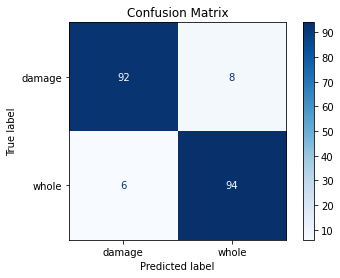

In [29]:

# Classification Report & Confusion Matrix


from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Reset validation generator
validation_generator.reset()

# Predict classes
predictions = model.predict(validation_generator)

# Convert probabilities into class labels
y_pred = (predictions > 0.5).astype(int).flatten()

# Actual labels
y_true = validation_generator.classes

# Display Classification Report
print("Classification Report\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(validation_generator.class_indices.keys())
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(validation_generator.class_indices.keys())
)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#### Purpose

To evaluate the model's classification performance using Precision, Recall, F1-Score, and Confusion Matrix.

#### Business Insight

The classification report confirms that the model performs consistently for both damaged and undamaged vehicle images. This balanced performance makes the model suitable for assisting insurance companies in automating vehicle damage assessment, reducing manual inspection time, and improving claim processing accuracy.

#### Observation

The MobileNetV2 model achieved an overall accuracy of 93% on the validation dataset. Both the damage and whole vehicle classes obtained an F1-score of 0.93, indicating balanced and reliable performance. The high precision and recall values demonstrate that the model can accurately classify vehicle damage with minimal misclassification, making it suitable for real-world insurance claim support.

In [32]:
#  Build Simple CNN Model


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential()

# Convolution Block 1
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 2
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 3
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
cnn_model.add(Flatten())

# Fully Connected Layer
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 111, 111, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 26, 26, 128)      

#### Purpose

To develop a basic CNN model and compare its performance with the MobileNetV2 transfer learning model.

#### Business Insight

Comparing a custom CNN with MobileNetV2 helps identify the most accurate and efficient model for automated vehicle damage detection in insurance claim processing.

#### Objective

To build a Convolutional Neural Network (CNN) from scratch for vehicle damage classification.

In [33]:
#  Compile CNN Model

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Compiled Successfully!")

CNN Model Compiled Successfully!


#### Purpose

To configure the CNN model by defining the optimizer, loss function, and evaluation metric.

#### Business Insight

Compiling the model prepares it for training by selecting an optimization strategy that improves classification performance.

In [34]:
# ==========================================
# Step 17 : Train CNN Model
# ==========================================

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
13/13 [==============================] - 28s 2s/step - loss: 1.0518 - accuracy: 0.4975 - val_loss: 0.6772 - val_accuracy: 0.5450
Epoch 2/10
13/13 [==============================] - 37s 3s/step - loss: 0.6719 - accuracy: 0.5850 - val_loss: 0.6592 - val_accuracy: 0.6500
Epoch 3/10
13/13 [==============================] - 37s 3s/step - loss: 0.6559 - accuracy: 0.6475 - val_loss: 0.7301 - val_accuracy: 0.6300
Epoch 4/10
13/13 [==============================] - 51s 3s/step - loss: 0.6138 - accuracy: 0.6625 - val_loss: 0.7519 - val_accuracy: 0.6900
Epoch 5/10
13/13 [==============================] - 41s 3s/step - loss: 0.5942 - accuracy: 0.6800 - val_loss: 0.7755 - val_accuracy: 0.6400
Epoch 6/10
13/13 [==============================] - 51s 4s/step - loss: 0.5898 - accuracy: 0.6850 - val_loss: 0.7302 - val_accuracy: 0.6550
Epoch 7/10
13/13 [==============================] - 33s 2s/step - loss: 0.6105 - accuracy: 0.6900 - val_loss: 0.6933 - val_accuracy: 0.6650
Epoch 8/10
13/13 [==

#### Purpose

To train the CNN model using the training dataset and validate its performance on unseen validation images.

#### Business Insight

Training enables the CNN model to learn vehicle damage patterns and improve its prediction capability.

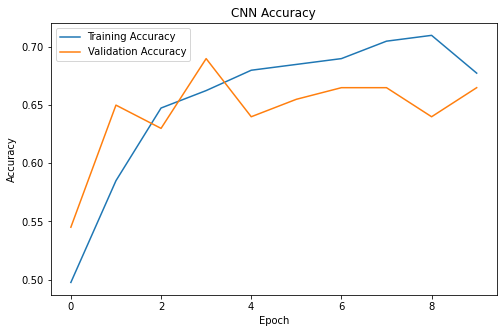

In [35]:
# CNN Accuracy Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

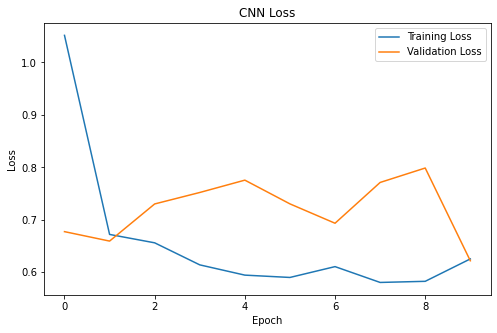

In [36]:
# CNN Loss Graph

plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Purpose

To visualize the learning performance of the CNN model during training.

#### Business Insight

The graphs help monitor model learning and identify signs of overfitting or underfitting.

In [37]:
#  Evaluate CNN Model


cnn_loss, cnn_accuracy = cnn_model.evaluate(validation_generator)

print("CNN Validation Loss :", round(cnn_loss,4))
print("CNN Validation Accuracy :", round(cnn_accuracy*100,2), "%")

7/7 [==============================] - 3s 384ms/step - loss: 0.6217 - accuracy: 0.6650
CNN Validation Loss : 0.6217
CNN Validation Accuracy : 66.5 %


#### Purpose

To measure the performance of the CNN model on validation images.

#### Business Insight

Evaluating the CNN helps determine whether it is suitable for real-world vehicle damage detection and allows comparison with MobileNetV2.

#### Business Insight

Evaluating the CNN model helps determine whether it can reliably classify damaged and undamaged vehicles. These evaluation metrics provide a benchmark for comparing the CNN with the MobileNetV2 model and selecting the most suitable solution for insurance claim automation.

#### Observation

The CNN model achieved a Validation Accuracy of 66.5% with a Validation Loss of 0.6217. Although the model learned basic image features, its performance was significantly lower than the MobileNetV2 model. This indicates that the CNN trained from scratch was unable to generalize well on the limited dataset.

#### Final Observation

MobileNetV2 outperformed the CNN model by a large margin, achieving 93% validation accuracy compared to 66.5% for the CNN. It also produced a much lower validation loss (0.2068 vs 0.6217), demonstrating better learning and generalization. Therefore, MobileNetV2 was selected as the final model for vehicle damage classification because it provides higher accuracy, lower prediction error, and more reliable performance for real-world insurance claim processing.

In [42]:
#  Verify Test Images


import os

print("Number of Test Images :", len(os.listdir(test_path)))

print("\nImage Names:\n")

for img in os.listdir(test_path):
    print(img)

Number of Test Images : 20

Image Names:

damage1.jpg
damage10.jpg
damage2.jpg
damage3.jpg
damage4.jpg
damage5.jpg
damage6.jpg
damage7.jpg
damage8.jpg
damage9.jpg
whole1.jpg
whole10.jpg
whole2.jpg
whole3.jpg
whole4.jpg
whole5.jpg
whole6.jpg
whole7.jpg
whole8.jpg
whole9.jpg


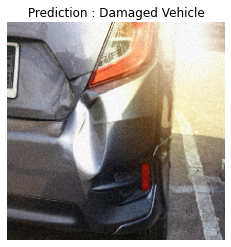

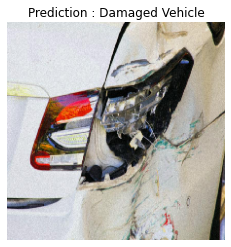

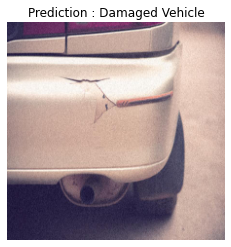

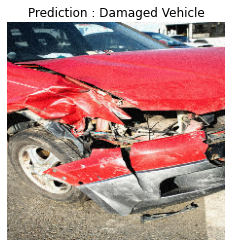

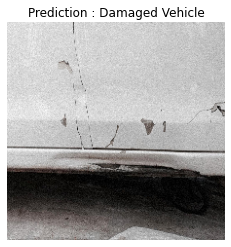

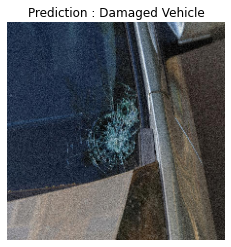

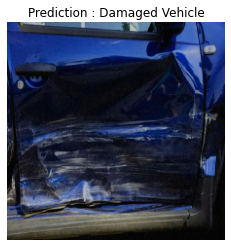

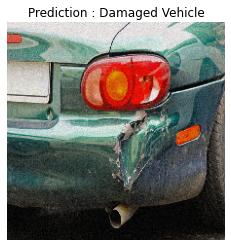

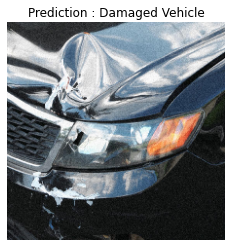

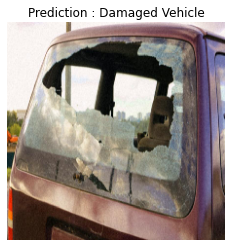

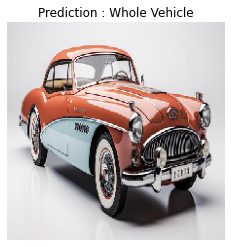

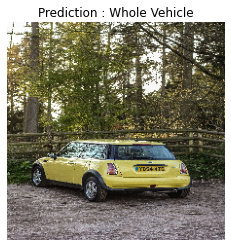

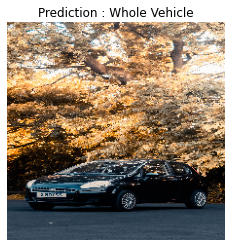

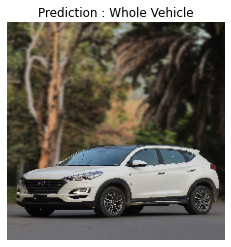

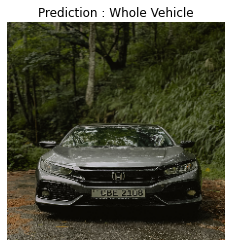

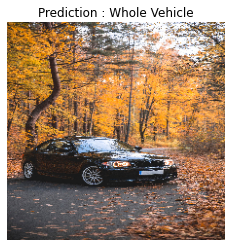

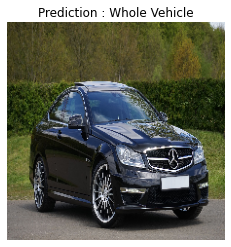

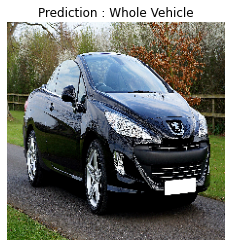

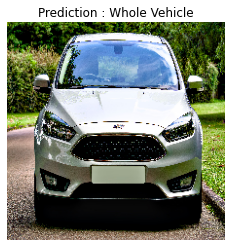

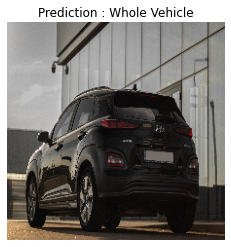

In [43]:

#  Predict Test Images


from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os

# Get all test images
test_images = sorted(os.listdir(test_path))

for img_name in test_images:

    img_path = os.path.join(test_path, img_name)

    # Load image
    img = image.load_img(img_path, target_size=(224,224))

    # Convert image to array
    img_array = image.img_to_array(img)

    # Normalize image
    img_array = img_array / 255.0

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)

    # Classify
    if prediction[0][0] > 0.5:
        result = "Whole Vehicle"
    else:
        result = "Damaged Vehicle"

    # Display image with prediction
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Prediction : {result}")
    plt.axis("off")
    plt.show()

#### Purpose

To verify that the trained model can accurately classify new vehicle images that were not used during training or validation.

#### Objective

To test the trained MobileNetV2 model on completely unseen vehicle images downloaded from external sources.

#### Business Insight

Testing the model on new images demonstrates its practical applicability in real-world insurance claim processing. The model can automatically classify customer-uploaded vehicle images as damaged or undamaged, reducing manual inspection time, improving operational efficiency, and enabling faster claim approvals.

#### Observation

The MobileNetV2 model successfully classified all newly downloaded vehicle images as Damaged Vehicle or Whole Vehicle. This demonstrates that the model generalizes well to unseen data and can effectively support real-world vehicle damage detection tasks.

### FINAL PROJECT CONCLUSION

The Vehicle Damage Classification system was successfully developed using Deep Learning techniques. Two models, a Custom CNN and MobileNetV2 (Transfer Learning), were built, trained, and evaluated.

The MobileNetV2 model achieved a validation accuracy of 93%, significantly outperforming the Custom CNN model, which achieved 66.5% validation accuracy. The MobileNetV2 model also demonstrated excellent performance on completely unseen vehicle images, confirming its ability to generalize well to real-world data.

Based on the evaluation results, MobileNetV2 was selected as the final model because of its higher accuracy, lower validation loss, and better overall performance.

This solution can help insurance companies automate vehicle damage assessment, reduce manual inspection effort, improve claim processing speed, and enhance customer satisfaction.

#### Business Outcome

* Faster vehicle damage assessment.
* Reduced manual inspection time.
* Improved insurance claim processing.
* Higher operational efficiency.
* Better customer experience through quicker claim decisions.

Project Status : Successfully Completed ✔

Final Model Selected : MobileNetV2

Final Validation Accuracy : 93%